# Wykrywanie Anomalii w Szeregach Czasowych
## NASA SMAP/MSL · Normalizing Flows (RealNVP) · Diffusion Models (DDPM) · LSTM Autoencoder

**Dawid Zawiślak · Jakub Worek**

---

System uczy się wyłącznie na danych normalnych, a następnie ocenia odchylenie każdej nowej próbki od wyuczonego rozkładu.  
Trzy podejścia są porównywane pod kątem **AUC-ROC**, **Precision**, **Recall** i **F1**.

In [2]:
import os
import io
import zipfile
import requests
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    roc_auc_score, precision_recall_fscore_support,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Urządzenie: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Urządzenie: cpu
PyTorch: 2.2.2


In [3]:
# ── Konfiguracja ──────────────────────────────────────────────────────────────
WINDOW_SIZE   = 100     # długość okna przesuwnego
TRAIN_STRIDE  = 5       # krok przy tworzeniu okien treningowych
BATCH_SIZE    = 64
EPOCHS_LSTM   = 40
EPOCHS_FLOW   = 40
EPOCHS_DIFF   = 40
LR            = 1e-3
HIDDEN_DIM    = 64      # LSTM hidden size
THRESHOLD_PCT = 95      # percentyl do wyznaczenia progu

# ── Ścieżki ───────────────────────────────────────────────────────────────────
DATA_DIR = './data'   # katalog z podfolderami train/ i test/

# labeled_anomalies.csv może leżeć obok notebooka LUB w DATA_DIR
import pathlib as _pl
_candidates = [_pl.Path('./labeled_anomalies.csv'),
               _pl.Path(DATA_DIR) / 'labeled_anomalies.csv']
LABELS_PATH = next((str(p) for p in _candidates if p.exists()), None)

if LABELS_PATH is None:
    raise FileNotFoundError(
        'Nie znaleziono labeled_anomalies.csv.\n'
        'Pobierz plik z:\n'
        '  https://raw.githubusercontent.com/khundman/telemanom'
        '/master/labeled_anomalies.csv\n'
        f'i umieść obok notebooka lub w {DATA_DIR}/'
    )

print(f'DATA_DIR    : {_pl.Path(DATA_DIR).resolve()}')
print(f'LABELS_PATH : {_pl.Path(LABELS_PATH).resolve()}')

# Kanały SMAP/MSL do ewaluacji
CHANNELS     = ['P-1', 'S-1', 'M-6', 'M-1']
MAIN_CHANNEL = 'P-1'   # kanał do szczegółowej wizualizacji


DATA_DIR    : /Users/dawidzawislak/rep/sequential_anomaly_detection/data
LABELS_PATH : /Users/dawidzawislak/rep/sequential_anomaly_detection/labeled_anomalies.csv


## 1. Dane — NASA SMAP / MSL

Zbiór telemetryczny NASA zawierający dane z satelity SMAP i łazika MSL.  
Każdy *kanał* to wielowymiarowy szereg czasowy z ręcznie oznaczonymi anomaliami.

- **train/** — dane normalne (do uczenia modeli)
- **test/**  — dane z anomaliami (do ewaluacji)
- `labeled_anomalies.csv` — zakresy anomalii dla każdego kanału

In [4]:
def load_channel(channel: str, data_dir: str = DATA_DIR):
    train = np.load(os.path.join(data_dir, 'train', f'{channel}.npy'))
    test  = np.load(os.path.join(data_dir, 'test',  f'{channel}.npy'))
    return train.astype(np.float32), test.astype(np.float32)


def build_labels(channel: str, test_len: int,
                 labels_path: str = None) -> np.ndarray:
    path = labels_path or LABELS_PATH
    df   = pd.read_csv(path)
    row  = df[df['chan_id'] == channel]
    lbl  = np.zeros(test_len, dtype=np.int32)
    for _, r in row.iterrows():
        for start, end in eval(r['anomaly_sequences']):
            lbl[start : end + 1] = 1
    return lbl


channel_data: dict = {}
for ch in CHANNELS:
    try:
        tr, te = load_channel(ch)
        lbl    = build_labels(ch, len(te))
        channel_data[ch] = {'train': tr, 'test': te, 'labels': lbl}
        pct = lbl.mean() * 100
        print(f'{ch:6s}  train={tr.shape}  test={te.shape}  '
              f'features={tr.shape[1]}  anomalie={pct:.1f}%')
    except FileNotFoundError as e:
        print(f'{ch}: brak pliku — {e}')


P-1     train=(2872, 25)  test=(8505, 25)  features=25  anomalie=8.8%
S-1     train=(2818, 25)  test=(7331, 25)  features=25  anomalie=6.1%
M-6     train=(1565, 55)  test=(2049, 55)  features=55  anomalie=8.8%
M-1     train=(2209, 55)  test=(2277, 55)  features=55  anomalie=50.1%


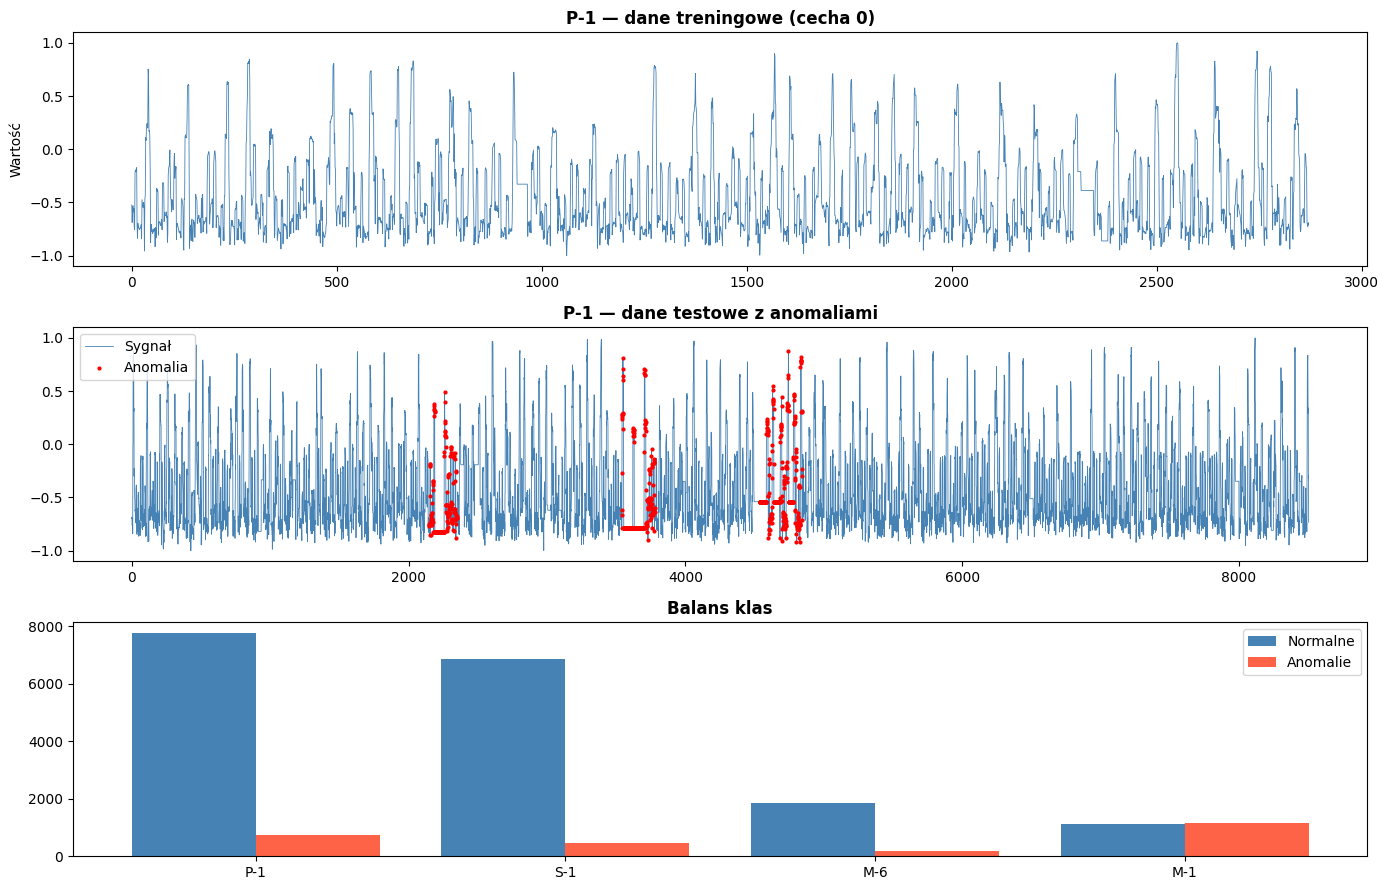

In [5]:
ch  = MAIN_CHANNEL
tr  = channel_data[ch]['train']
te  = channel_data[ch]['test']
lbl = channel_data[ch]['labels']

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

axes[0].plot(tr[:, 0], color='steelblue', lw=0.6)
axes[0].set_title(f'{ch} — dane treningowe (cecha 0)', fontweight='bold')
axes[0].set_ylabel('Wartość')

axes[1].plot(te[:, 0], color='steelblue', lw=0.6, label='Sygnał')
anom_idx = np.where(lbl == 1)[0]
if len(anom_idx):
    axes[1].scatter(anom_idx, te[anom_idx, 0], color='red', s=4,
                    label='Anomalia', zorder=3)
axes[1].set_title(f'{ch} — dane testowe z anomaliami', fontweight='bold')
axes[1].legend()

chs_ok = [c for c in CHANNELS if c in channel_data]
x = np.arange(len(chs_ok))
norm_c = [len(channel_data[c]['labels']) - channel_data[c]['labels'].sum() for c in chs_ok]
anom_c = [channel_data[c]['labels'].sum() for c in chs_ok]
axes[2].bar(x - 0.2, norm_c, 0.4, label='Normalne',  color='steelblue')
axes[2].bar(x + 0.2, anom_c, 0.4, label='Anomalie', color='tomato')
axes[2].set_xticks(x); axes[2].set_xticklabels(chs_ok)
axes[2].set_title('Balans klas', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Preprocessing

1. **StandardScaler** — normalizacja cech (fit na danych treningowych, transform na testowych)
2. **Sliding window** — tworzymy okna o długości `WINDOW_SIZE`  
   - Trening: krok `TRAIN_STRIDE` (szybszy trening, mniej pokrywających się próbek)
   - Test: krok 1 (każdy punkt dostaje swój score)
3. **Etykiety okien** — okno = anomalne, jeśli ≥ 1 punkt w nim jest anomalny

In [6]:
def make_windows(data: np.ndarray, ws: int, stride: int) -> np.ndarray:
    return np.stack([
        data[i : i + ws]
        for i in range(0, len(data) - ws + 1, stride)
    ]).astype(np.float32)


def window_labels(labels: np.ndarray, ws: int) -> np.ndarray:
    return np.array(
        [int(labels[i : i + ws].any()) for i in range(len(labels) - ws + 1)],
        dtype=np.int32
    )


def preprocess(train: np.ndarray, test: np.ndarray, ws: int = WINDOW_SIZE,
               stride: int = TRAIN_STRIDE):
    scaler = StandardScaler()
    tr_norm = scaler.fit_transform(train)
    te_norm = scaler.transform(test)
    return make_windows(tr_norm, ws, stride), make_windows(te_norm, ws, 1), scaler


X_train, X_test, scaler = preprocess(
    channel_data[MAIN_CHANNEL]['train'],
    channel_data[MAIN_CHANNEL]['test']
)
y_test = window_labels(channel_data[MAIN_CHANNEL]['labels'], WINDOW_SIZE)

INPUT_DIM = X_train.shape[2]
FLAT_DIM  = WINDOW_SIZE * INPUT_DIM

print(f'X_train : {X_train.shape}  (okna × czas × cechy)')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}   anomalie={y_test.sum()} ({100*y_test.mean():.1f}%)')
print(f'INPUT_DIM={INPUT_DIM}  FLAT_DIM={FLAT_DIM}')

train_tensor = torch.FloatTensor(X_train)
test_tensor  = torch.FloatTensor(X_test)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader  = DataLoader(TensorDataset(test_tensor),  batch_size=BATCH_SIZE, shuffle=False)

X_train : (555, 100, 25)  (okna × czas × cechy)
X_test  : (8406, 100, 25)
y_test  : (8406,)   anomalie=1048 (12.5%)
INPUT_DIM=25  FLAT_DIM=2500


## 3. Model 1 — LSTM Autoencoder

Sekwencyjny autoencoder oparty na LSTM:
- **Encoder**: LSTM redukuje sekwencję do wektora ukrytego `h`
- **Decoder**: LSTM rekonstruuje sekwencję z `h` (powielany na każdy krok)
- **Anomaly score**: `MSE(x, x̂)` uśrednione po czasie i cechach

Model uczy się na danych normalnych → anomalie mają wyższy błąd rekonstrukcji.

In [7]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64, num_layers: int = 2,
                 dropout: float = 0.1):
        super().__init__()
        dp = dropout if num_layers > 1 else 0.0
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers,
                               batch_first=True, dropout=dp)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers,
                               batch_first=True, dropout=dp)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, (h, _) = self.encoder(x)
        # powiel ostatni stan ukryty na każdy krok czasowy
        dec_in = h[-1].unsqueeze(1).expand(-1, x.size(1), -1)
        recon, _ = self.decoder(dec_in)
        return recon

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        return torch.mean((x - self.forward(x)) ** 2, dim=(1, 2))


def train_lstm(model: nn.Module, loader: DataLoader, epochs: int,
               lr: float = LR, tag: str = '') -> list:
    opt  = optim.Adam(model.parameters(), lr=lr)
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    crit = nn.MSELoss()
    model.train()
    losses = []
    for ep in range(1, epochs + 1):
        running = 0.0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(batch), batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()
        sch.step()
        avg = running / len(loader)
        losses.append(avg)
        if ep % 10 == 0:
            print(f'  [{tag}] ep {ep:3d}/{epochs}  loss={avg:.6f}')
    return losses


lstm_model = LSTMAutoencoder(INPUT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
nparams = sum(p.numel() for p in lstm_model.parameters())
print(f'LSTM Autoencoder — {nparams:,} parametrów')
lstm_losses = train_lstm(lstm_model, train_loader, EPOCHS_LSTM, tag='LSTM')

LSTM Autoencoder — 70,876 parametrów
  [LSTM] ep  10/40  loss=0.638980
  [LSTM] ep  20/40  loss=0.642119
  [LSTM] ep  30/40  loss=0.635892
  [LSTM] ep  40/40  loss=0.638823


In [ ]:
@torch.no_grad()
def score_loader(model: nn.Module, loader: DataLoader,
                 score_fn) -> np.ndarray:
    model.eval()
    out = []
    for (batch,) in loader:
        out.append(score_fn(batch.to(DEVICE)).detach().cpu().numpy())
    return np.concatenate(out)


lstm_scores = score_loader(lstm_model, test_loader, lstm_model.anomaly_score)

plt.figure(figsize=(10, 3))
plt.plot(lstm_losses, color='steelblue')
plt.title('LSTM Autoencoder — krzywa uczenia', fontweight='bold')
plt.xlabel('Epoka'); plt.ylabel('MSE Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'LSTM scores — min={lstm_scores.min():.6f}  '
      f'mean={lstm_scores.mean():.6f}  max={lstm_scores.max():.6f}')

## 4. Model 2 — Normalizing Flows (RealNVP)

RealNVP to przepływ normalizujący oparty na warstwach **affine coupling**:
- Wejście (spłaszczone okno) przepuszczamy przez `n_flows` warstw
- Każda warstwa dzieli cechy na dwa podzbiory i transformuje jeden przy użyciu skalowalnej funkcji `s` i translacji `t` drugiego
- Transformacja jest odwracalna, a jakobian jest łatwy do obliczenia
- **Anomaly score**: ujemna log-likelihood `−log p(x)`

Dane normalne mają wysokie `p(x)`, anomalie niskie.

In [ ]:
class AffineCoupling(nn.Module):
    def __init__(self, dim: int, mask: torch.Tensor, hidden: int = 256):
        super().__init__()
        self.register_buffer('mask', mask)

        def mlp(out_act=None):
            layers: list = [
                nn.Linear(dim, hidden), nn.LeakyReLU(0.2),
                nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
                nn.Linear(hidden, dim),
            ]
            if out_act:
                layers.append(out_act)
            return nn.Sequential(*layers)

        self.s_net = mlp(nn.Tanh())
        self.t_net = mlp()

    def forward(self, x: torch.Tensor):
        xm  = x * self.mask
        s   = self.s_net(xm) * (1 - self.mask)
        t   = self.t_net(xm) * (1 - self.mask)
        z   = xm + (1 - self.mask) * (x * torch.exp(s) + t)
        ldet = (s * (1 - self.mask)).sum(dim=1)
        return z, ldet

    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        zm = z * self.mask
        s  = self.s_net(zm) * (1 - self.mask)
        t  = self.t_net(zm) * (1 - self.mask)
        return zm + (1 - self.mask) * ((z - t) * torch.exp(-s))


class RealNVP(nn.Module):
    def __init__(self, dim: int, n_flows: int = 8, hidden: int = 256):
        super().__init__()
        self.dim = dim
        masks = []
        for i in range(n_flows):
            m = torch.zeros(dim)
            m[:dim // 2] = float(i % 2 == 0)
            m[dim // 2:] = float(i % 2 == 1)
            masks.append(m)
        self.flows = nn.ModuleList(
            [AffineCoupling(dim, m, hidden) for m in masks]
        )

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        z, ldet = x, torch.zeros(x.size(0), device=x.device)
        for flow in self.flows:
            z, ld = flow(z)
            ldet  = ldet + ld
        log_pz = -0.5 * (z ** 2 + np.log(2 * np.pi)).sum(dim=1)
        return log_pz + ldet

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return -self.log_prob(x)   # NLL (strata treningowa)

    def anomaly_score(self, x: torch.Tensor) -> torch.Tensor:
        return -self.log_prob(x)


def train_flow(model: nn.Module, loader: DataLoader, epochs: int,
               lr: float = LR, tag: str = '') -> list:
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    model.train()
    losses = []
    for ep in range(1, epochs + 1):
        running = 0.0
        for (batch,) in loader:
            flat = batch.to(DEVICE).view(batch.size(0), -1)
            opt.zero_grad()
            loss = model(flat).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()
        sch.step()
        avg = running / len(loader)
        losses.append(avg)
        if ep % 10 == 0:
            print(f'  [{tag}] ep {ep:3d}/{epochs}  NLL={avg:.4f}')
    return losses


flow_model = RealNVP(FLAT_DIM, n_flows=8, hidden=256).to(DEVICE)
nparams = sum(p.numel() for p in flow_model.parameters())
print(f'RealNVP — {nparams:,} parametrów')
flow_losses = train_flow(flow_model, train_loader, EPOCHS_FLOW, tag='RealNVP')

In [ ]:
@torch.no_grad()
def score_flow_loader(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    out = []
    for (batch,) in loader:
        flat = batch.to(DEVICE).view(batch.size(0), -1)
        out.append(model.anomaly_score(flat).detach().cpu().numpy())
    return np.concatenate(out)


flow_scores = score_flow_loader(flow_model, test_loader)

plt.figure(figsize=(10, 3))
plt.plot(flow_losses, color='darkorange')
plt.title('RealNVP — krzywa uczenia (NLL)', fontweight='bold')
plt.xlabel('Epoka'); plt.ylabel('−log p(x)'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'RealNVP scores — min={flow_scores.min():.2f}  '
      f'mean={flow_scores.mean():.2f}  max={flow_scores.max():.2f}')

## 5. Model 3 — Diffusion Model (DDPM)

Denoising Diffusion Probabilistic Model zaadaptowany do szeregów czasowych:

**Proces forward** (dodawanie szumu):  
$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}\, x_0,\; (1-\bar{\alpha}_t)\mathbf{I})$

**Trening**: sieć $\epsilon_\theta(x_t, t)$ uczy się odgadywać szum $\epsilon$ dodany do $x_0$.

**Anomaly score**: średni błąd predykcji szumu dla kroków z zakresu $[T/4, T/2]$.  
Dane normalne są lepiej „zrozumiane” przez sieć → niższy błąd → niższy score.

Sinusoidalne osadzenie kroku $t$ kondycjonuje sieć denoisingową.

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        half = dim // 2
        freqs = torch.exp(-np.log(10_000) * torch.arange(half).float() / half)
        self.register_buffer('freqs', freqs)
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.SiLU(), nn.Linear(dim * 2, dim)
        )

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        args = t.float().unsqueeze(1) * self.freqs.unsqueeze(0)
        emb  = torch.cat([args.sin(), args.cos()], dim=1)
        return self.proj(emb)


class DenoisingMLP(nn.Module):
    def __init__(self, input_dim: int, hidden: int = 512, time_dim: int = 128):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(time_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, input_dim),
        )

    def forward(self, x_noisy: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([x_noisy, self.time_emb(t)], dim=1))


class DDPM(nn.Module):
    def __init__(self, input_dim: int, T: int = 200,
                 hidden: int = 512, time_dim: int = 128):
        super().__init__()
        self.T       = T
        self.denoiser = DenoisingMLP(input_dim, hidden, time_dim)

        betas      = torch.linspace(1e-4, 0.02, T)
        alphas     = 1.0 - betas
        alpha_bars = torch.cumprod(alphas, 0)
        self.register_buffer('betas',      betas)
        self.register_buffer('alphas',     alphas)
        self.register_buffer('alpha_bars', alpha_bars)

    def q_sample(self, x0: torch.Tensor, t: torch.Tensor,
                 noise: torch.Tensor | None = None):
        if noise is None:
            noise = torch.randn_like(x0)
        ab   = self.alpha_bars[t].view(-1, 1)
        x_t  = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
        return x_t, noise

    def forward(self, x0: torch.Tensor) -> torch.Tensor:
        t    = torch.randint(0, self.T, (x0.size(0),), device=x0.device)
        xt, noise = self.q_sample(x0, t)
        return nn.functional.mse_loss(self.denoiser(xt, t), noise)

    @torch.no_grad()
    def anomaly_score(self, x0: torch.Tensor, n_avg: int = 20) -> torch.Tensor:
        self.eval()
        scores = torch.zeros(x0.size(0), device=x0.device)
        lo, hi = self.T // 4, self.T // 2
        for _ in range(n_avg):
            t = torch.randint(lo, hi, (x0.size(0),), device=x0.device)
            xt, noise = self.q_sample(x0, t)
            pred      = self.denoiser(xt, t)
            scores   += ((pred - noise) ** 2).mean(dim=1)
        return scores / n_avg


def train_diffusion(model: nn.Module, loader: DataLoader, epochs: int,
                    lr: float = LR, tag: str = '') -> list:
    opt = optim.AdamW(model.parameters(), lr=lr)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    model.train()
    losses = []
    for ep in range(1, epochs + 1):
        running = 0.0
        for (batch,) in loader:
            flat = batch.to(DEVICE).view(batch.size(0), -1)
            opt.zero_grad()
            loss = model(flat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            running += loss.item()
        sch.step()
        avg = running / len(loader)
        losses.append(avg)
        if ep % 10 == 0:
            print(f'  [{tag}] ep {ep:3d}/{epochs}  loss={avg:.6f}')
    return losses


diff_model = DDPM(FLAT_DIM, T=200, hidden=512, time_dim=128).to(DEVICE)
nparams = sum(p.numel() for p in diff_model.parameters())
print(f'DDPM — {nparams:,} parametrów')
diff_losses = train_diffusion(diff_model, train_loader, EPOCHS_DIFF, tag='DDPM')

In [ ]:
@torch.no_grad()
def score_diff_loader(model: nn.Module, loader: DataLoader,
                      n_avg: int = 20) -> np.ndarray:
    model.eval()
    out = []
    for (batch,) in loader:
        flat = batch.to(DEVICE).view(batch.size(0), -1)
        out.append(model.anomaly_score(flat, n_avg).detach().cpu().numpy())
    return np.concatenate(out)


print('Obliczanie scorów DDPM (może chwilę potrwać)...')
diff_scores = score_diff_loader(diff_model, test_loader, n_avg=20)

plt.figure(figsize=(10, 3))
plt.plot(diff_losses, color='forestgreen')
plt.title('DDPM — krzywa uczenia', fontweight='bold')
plt.xlabel('Epoka'); plt.ylabel('MSE Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'DDPM scores — min={diff_scores.min():.6f}  '
      f'mean={diff_scores.mean():.6f}  max={diff_scores.max():.6f}')

## 6. Próg decyzyjny i ocena

Próg wyznaczamy jako **percentyl 95** scorów na danych treningowych:  
→ zakładamy, że ≤ 5% próbek treningowych to potencjalne szumy / łagodne odchylenia.

Metryki:
| Metryka | Opis |
|---|---|
| AUC-ROC | Niezależna od progu, mierzy zdolność separacji |
| Precision | Jak wiele alarmów jest prawdziwymi anomaliami |
| Recall | Jak wiele anomalii zostało wykrytych |
| F1 | Harmonia precision i recall |

In [ ]:
def compute_threshold(scores: np.ndarray, pct: float = THRESHOLD_PCT) -> float:
    return float(np.percentile(scores, pct))


def evaluate(scores: np.ndarray, labels: np.ndarray,
             threshold: float) -> dict:
    preds = (scores > threshold).astype(int)
    auc   = roc_auc_score(labels, scores)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average='binary', zero_division=0)
    return {'AUC-ROC': auc, 'Precision': p, 'Recall': r, 'F1': f1,
            'threshold': threshold}


# Progi na próbkach treningowych (pierwsze 2000 okien)
n_thr = min(2000, len(train_tensor))
sample_idx = np.random.choice(len(train_tensor), n_thr, replace=False)
tr_sample = train_tensor[sample_idx].to(DEVICE)

with torch.no_grad():
    lstm_tr_scores = lstm_model.anomaly_score(tr_sample).detach().cpu().numpy()
    flow_tr_scores = flow_model.anomaly_score(
        tr_sample.view(n_thr, -1)).detach().cpu().numpy()
    diff_tr_scores = diff_model.anomaly_score(
        tr_sample.view(n_thr, -1), n_avg=10).detach().cpu().numpy()

lstm_thr = compute_threshold(lstm_tr_scores)
flow_thr = compute_threshold(flow_tr_scores)
diff_thr = compute_threshold(diff_tr_scores)

print('Progi (percentyl 95 — dane treningowe):')
print(f'  LSTM Autoencoder : {lstm_thr:.6f}')
print(f'  RealNVP          : {flow_thr:.4f}')
print(f'  DDPM             : {diff_thr:.6f}')

lstm_metrics = evaluate(lstm_scores, y_test, lstm_thr)
flow_metrics = evaluate(flow_scores, y_test, flow_thr)
diff_metrics = evaluate(diff_scores, y_test, diff_thr)

results = pd.DataFrame({
    'LSTM Autoencoder': lstm_metrics,
    'RealNVP (NF)':     flow_metrics,
    'DDPM (Diffusion)': diff_metrics,
}).T.drop(columns=['threshold'])

print(f'\n══ Wyniki — kanał {MAIN_CHANNEL} ══')
print(results.round(4).to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmapa metryk
sns.heatmap(
    results.astype(float), annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title(f'Metryki modeli — {MAIN_CHANNEL}', fontweight='bold')

# Krzywe ROC
fpr_l, tpr_l, _ = roc_curve(y_test, lstm_scores)
fpr_f, tpr_f, _ = roc_curve(y_test, flow_scores)
fpr_d, tpr_d, _ = roc_curve(y_test, diff_scores)

axes[1].plot(fpr_l, tpr_l, lw=2, color='steelblue',
             label=f"LSTM AE   AUC={lstm_metrics['AUC-ROC']:.3f}")
axes[1].plot(fpr_f, tpr_f, lw=2, color='darkorange',
             label=f"RealNVP   AUC={flow_metrics['AUC-ROC']:.3f}")
axes[1].plot(fpr_d, tpr_d, lw=2, color='forestgreen',
             label=f"DDPM      AUC={diff_metrics['AUC-ROC']:.3f}")
axes[1].plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Krzywe ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Anomaly scores w czasie + próg
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

sig = channel_data[MAIN_CHANNEL]['test'][:, 0]
t_axis = np.arange(len(y_test))

axes[0].plot(sig[:len(y_test)], color='steelblue', lw=0.5)
axes[0].fill_between(t_axis, sig.min(), sig[:len(y_test)],
                     where=(y_test == 1), alpha=0.3, color='red',
                     label='Anomalia (GT)')
axes[0].set_title(f'{MAIN_CHANNEL} — sygnał testowy z ground truth', fontweight='bold')
axes[0].legend()

for ax, scores, thr, name, color in [
    (axes[1], lstm_scores, lstm_thr, 'LSTM Autoencoder', 'steelblue'),
    (axes[2], flow_scores, flow_thr, 'RealNVP (NF)',    'darkorange'),
    (axes[3], diff_scores, diff_thr, 'DDPM (Diffusion)','forestgreen'),
]:
    ax.plot(scores, color=color, lw=0.5, label='Score')
    ax.axhline(thr, color='red', ls='--', lw=1.2,
               label=f'Próg (p{THRESHOLD_PCT})')
    ax.fill_between(t_axis, thr, scores,
                    where=(scores > thr), alpha=0.35, color='red')
    ax.set_title(f'{name} — Anomaly Score', fontweight='bold')
    ax.legend(loc='upper right')

axes[3].set_xlabel('Numer okna')
plt.tight_layout()
plt.show()

## 7. Ewaluacja na wielu kanałach

Trenujemy LSTM i RealNVP na każdym kanale (krótszy trening = 20 epok)  
i porównujemy AUC-ROC oraz F1.

In [ ]:
def run_channel(channel: str, epochs: int = 20) -> dict | None:
    if channel not in channel_data:
        return None

    Xtr, Xte, _ = preprocess(
        channel_data[channel]['train'],
        channel_data[channel]['test']
    )
    yt = window_labels(channel_data[channel]['labels'], WINDOW_SIZE)

    if yt.sum() == 0:
        print(f'  {channel}: brak anomalii — pomijam')
        return None

    idim  = Xtr.shape[2]
    fdim  = WINDOW_SIZE * idim
    tr_t  = torch.FloatTensor(Xtr)
    te_t  = torch.FloatTensor(Xte)
    tr_ld = DataLoader(TensorDataset(tr_t), batch_size=BATCH_SIZE,
                       shuffle=True, drop_last=True)
    te_ld = DataLoader(TensorDataset(te_t), batch_size=BATCH_SIZE)

    n_thr = min(1000, len(tr_t))
    idx   = np.random.choice(len(tr_t), n_thr, replace=False)

    # LSTM
    m_lstm = LSTMAutoencoder(idim, HIDDEN_DIM).to(DEVICE)
    train_lstm(m_lstm, tr_ld, epochs, tag=f'{channel}/LSTM')
    with torch.no_grad():
        tr_s = m_lstm.anomaly_score(tr_t[idx].to(DEVICE)).detach().cpu().numpy()
    te_s     = score_loader(m_lstm, te_ld, m_lstm.anomaly_score)
    lstm_m   = evaluate(te_s, yt, compute_threshold(tr_s))

    # RealNVP
    m_flow = RealNVP(fdim, n_flows=6, hidden=128).to(DEVICE)
    train_flow(m_flow, tr_ld, epochs, tag=f'{channel}/NF')
    with torch.no_grad():
        ftr_s = m_flow.anomaly_score(
            tr_t[idx].to(DEVICE).view(n_thr, -1)).detach().cpu().numpy()
    fte_s   = score_flow_loader(m_flow, te_ld)
    flow_m  = evaluate(fte_s, yt, compute_threshold(ftr_s))

    return {
        'LSTM  AUC': lstm_m['AUC-ROC'],
        'LSTM  F1':  lstm_m['F1'],
        'NF    AUC': flow_m['AUC-ROC'],
        'NF    F1':  flow_m['F1'],
    }


all_results: dict = {}
for ch in CHANNELS:
    print(f'\n── Kanał: {ch} ──')
    res = run_channel(ch, epochs=20)
    if res:
        all_results[ch] = res

if all_results:
    df_all = pd.DataFrame(all_results).T
    print('\n══ Podsumowanie wszystkich kanałów ══')
    print(df_all.round(4).to_string())

In [ ]:
if all_results:
    fig, ax = plt.subplots(figsize=(11, 4))
    x  = np.arange(len(df_all))
    w  = 0.2
    ax.bar(x - 1.5*w, df_all['LSTM  AUC'], w, label='LSTM  AUC', color='steelblue')
    ax.bar(x - 0.5*w, df_all['LSTM  F1'],  w, label='LSTM  F1',  color='lightblue')
    ax.bar(x + 0.5*w, df_all['NF    AUC'], w, label='NF    AUC', color='darkorange')
    ax.bar(x + 1.5*w, df_all['NF    F1'],  w, label='NF    F1',  color='moccasin')
    ax.set_xticks(x); ax.set_xticklabels(df_all.index, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Wartość metryki')
    ax.set_title('Porównanie LSTM vs RealNVP na wszystkich kanałach', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 8. Podsumowanie

### Wyniki (kanał główny)

Tabela poniżej zestawia wszystkie trzy modele.

In [ ]:
print('═' * 55)
print(f' Podsumowanie — kanał {MAIN_CHANNEL}')
print('═' * 55)
print(results.round(4).to_string())
print()

best_auc = results['AUC-ROC'].idxmax()
best_f1  = results['F1'].idxmax()
print(f'Najlepsze AUC-ROC : {best_auc}  ({results.loc[best_auc, "AUC-ROC"]:.4f})')
print(f'Najlepsze F1      : {best_f1}   ({results.loc[best_f1, "F1"]:.4f})')

print()
print('Charakterystyka modeli:')
print('  LSTM Autoencoder — efektywny dla lokalnych, sekwencyjnych anomalii;')
print('                     szybki trening, niskie zapotrzebowanie na pamięć.')
print('  RealNVP (NF)     — modeluje globalny rozkład danych; silny gdy anomalie')
print('                     to subtelne odchylenia statystyczne.')
print('  DDPM             — generatywny, odporny na złożone wzorce; wolniejszy,')
print('                     ale dobrze generalizuje na różne typy anomalii.')